<a href="https://colab.research.google.com/github/Pulkit-060207/Python-EDA-project/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       

/tmp/ipykernel_1421/3005721221.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


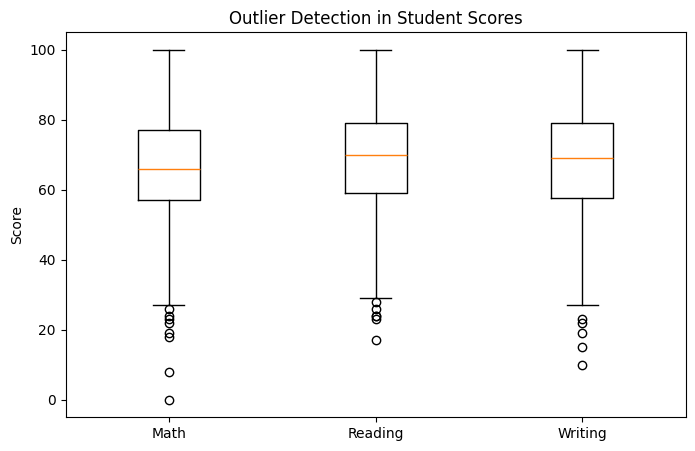

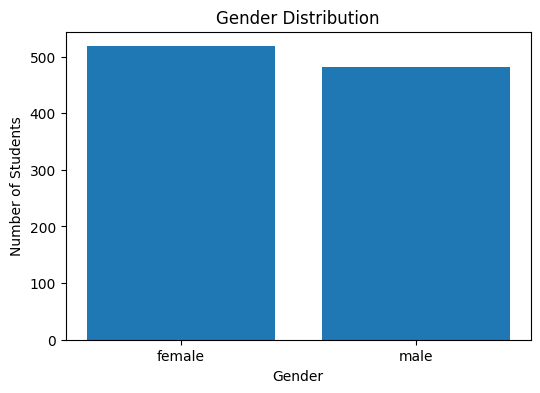

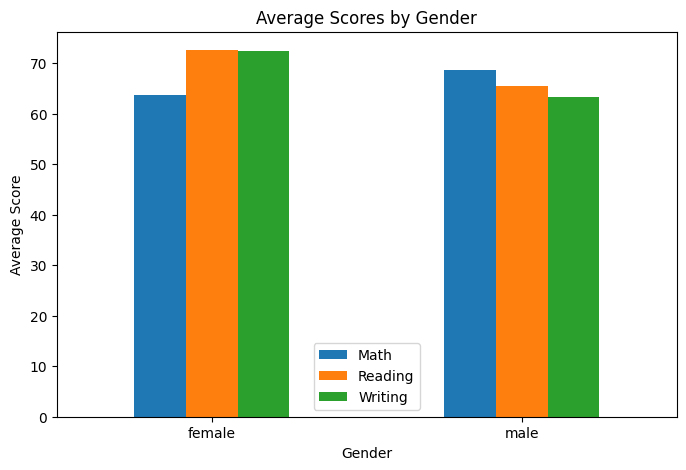

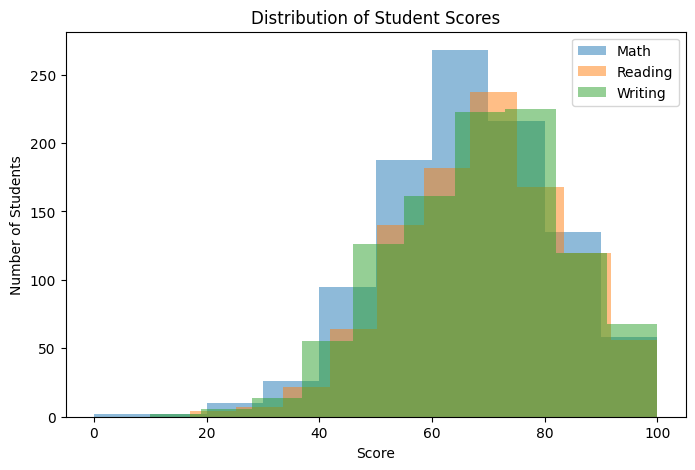

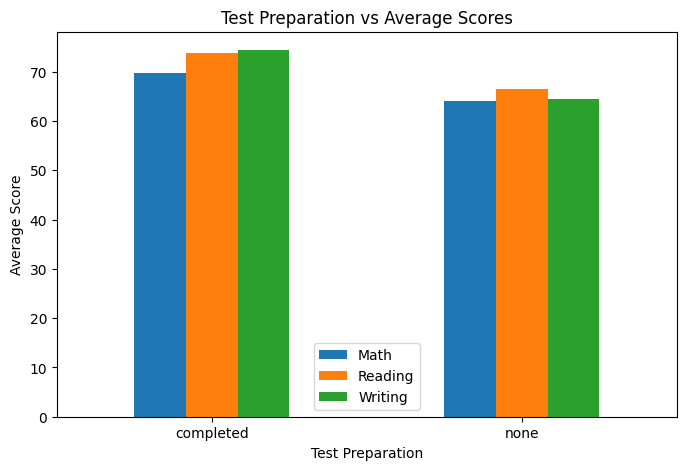

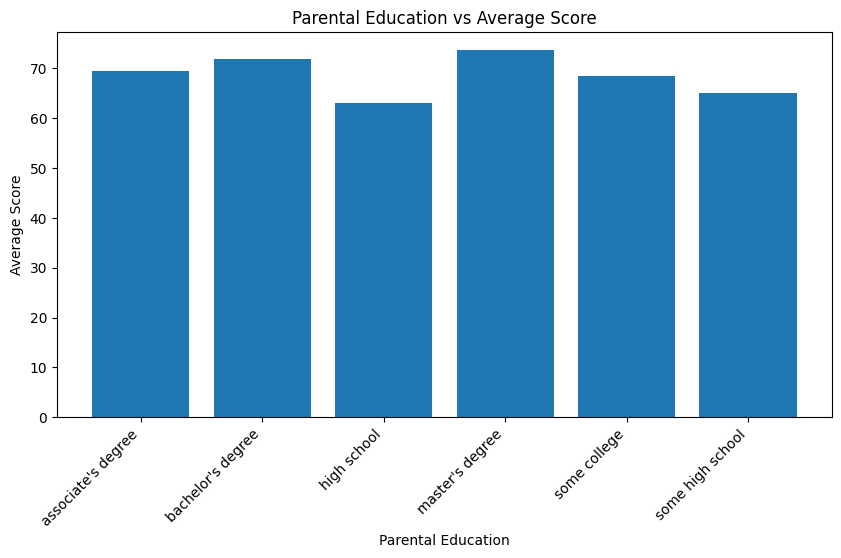

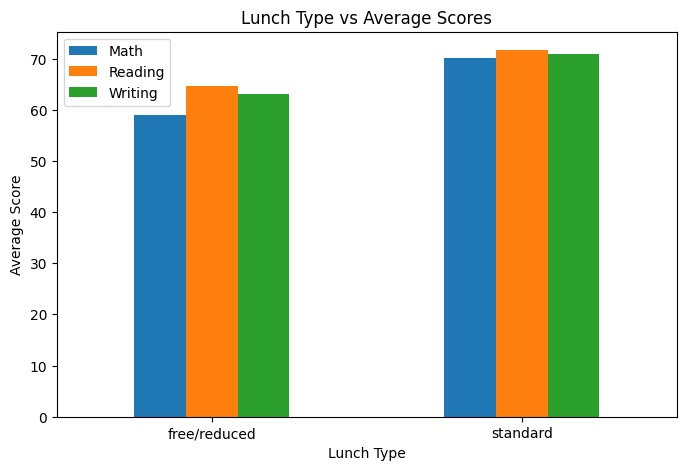

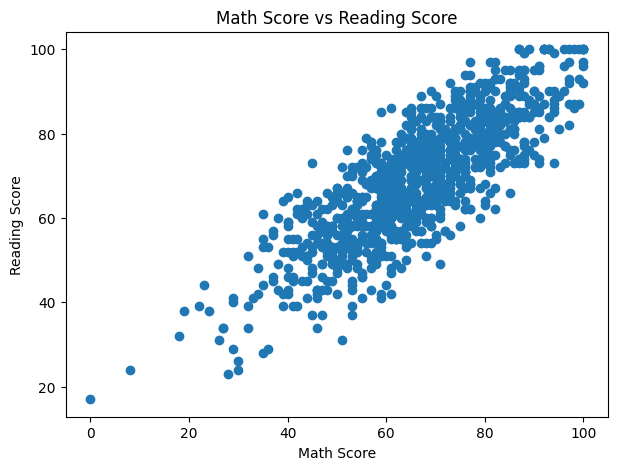

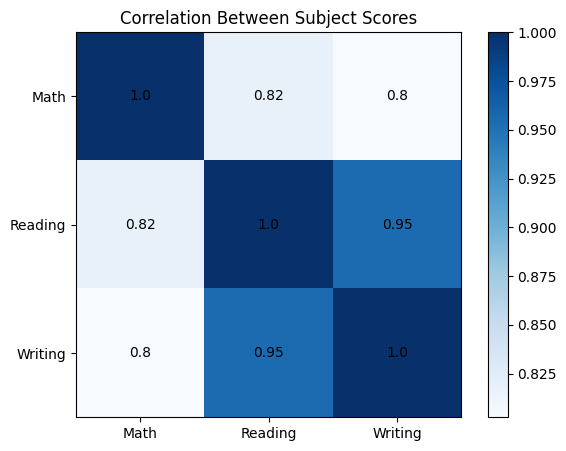

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

df.columns = [
    "gender",
    "race_ethnicity",
    "parental_education",
    "lunch",
    "test_preparation",
    "math_score",
    "reading_score",
    "writing_score"
]

numeric_cols = ["math_score", "reading_score", "writing_score"]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = [
    "gender",
    "race_ethnicity",
    "parental_education",
    "lunch",
    "test_preparation"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nOutliers:")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ":", len(outliers), "outliers")

plt.figure(figsize=(8, 5))
plt.boxplot(
    [df["math_score"], df["reading_score"], df["writing_score"]],
    tick_labels=["Math", "Reading", "Writing"]
)
plt.title("Outlier Detection in Student Scores")
plt.ylabel("Score")
plt.show()

gender_count = df["gender"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(gender_count.index, gender_count.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

gender_scores = df.groupby("gender")[numeric_cols].mean()

gender_scores.plot(kind="bar", figsize=(8, 5))
plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(["Math", "Reading", "Writing"])
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["math_score"], bins=10, alpha=0.5, label="Math")
plt.hist(df["reading_score"], bins=10, alpha=0.5, label="Reading")
plt.hist(df["writing_score"], bins=10, alpha=0.5, label="Writing")
plt.title("Distribution of Student Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

prep_scores = df.groupby("test_preparation")[numeric_cols].mean()

prep_scores.plot(kind="bar", figsize=(8, 5))
plt.title("Test Preparation vs Average Scores")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(["Math", "Reading", "Writing"])
plt.show()

parent_score = df.groupby("parental_education")[numeric_cols].mean()
parent_score["average"] = parent_score.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(parent_score.index, parent_score["average"])
plt.title("Parental Education vs Average Score")
plt.xlabel("Parental Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.show()

lunch_score = df.groupby("lunch")[numeric_cols].mean()

lunch_score.plot(kind="bar", figsize=(8, 5))
plt.title("Lunch Type vs Average Scores")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(["Math", "Reading", "Writing"])
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(df["math_score"], df["reading_score"])
plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

correlation = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
plt.imshow(correlation, cmap="Blues")
plt.colorbar()

plt.xticks(range(3), ["Math", "Reading", "Writing"])
plt.yticks(range(3), ["Math", "Reading", "Writing"])

plt.title("Correlation Between Subject Scores")

for i in range(3):
    for j in range(3):
        plt.text(
            j, i, round(correlation.iloc[i, j], 2),
            ha="center", va="center"
        )

plt.show()